# Домашнее задание: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов (+1 бонусный балл).


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающего дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
# !pip install matplotlib
# !pip install pandas
# !pip install scikit-learn

In [2]:
import math,numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [3]:
n_k1, n_k2 = 8, 2
N = n_k1 + n_k2

p = np.array([n_k1 / N, n_k2 / N])
entropy = -np.sum(p * np.log(p)) 
print("Задание 1.1")
print(f"Энтропия: {round(entropy, 2)}\n")

Задание 1.1
Энтропия: 0.5



**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [4]:
gini_parent = np.sum(p * (1 - p))
gini_left   = 0.0
gini_right  = 0.0

Q = gini_parent - (n_k1 / N) * gini_left - (n_k2 / N) * gini_right

print("Задание 1.2")
print(f"Gini impurity of parent    : {gini_parent:.5f}")
print(f"Information gain (Q)       : {Q:.5f}\n")

Задание 1.2
Gini impurity of parent    : 0.32000
Information gain (Q)       : 0.32000



**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [5]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

X = np.arange(10).reshape(-1, 1)
y = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47], dtype=float)

tree = DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
tree.fit(X, y)


print("Задание 1.3")
print(f"Значения               : {tree}")
print(f"Предсказания           : {tree.predict(X)}")

Задание 1.3
Значения               : DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
Предсказания           : [40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6]


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [6]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [7]:
# помощник
def _variance(sum_y, sum_y2, n):
    """несмещённая дисперсия (формула через суммы)"""
    return sum_y2 / n - (sum_y / n) ** 2

def find_best_split(
    feature_vector: Union[np.ndarray, pd.Series],
    target_vector:  Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:

    x = np.asarray(feature_vector)
    y = np.asarray(target_vector)
    n = y.shape[0]

    if feature_type == "real":
        idx = np.argsort(x).astype(int)
        x_sorted, y_sorted = x[idx], y[idx]

        diff = np.diff(x_sorted) != 0
        if not diff.any():
            return np.array([]), np.array([]), None, None
        
        thresholds = (x_sorted[:-1] + x_sorted[1:]) / 2  # серединки
        thresholds = thresholds[diff]                    # убираем дубликаты
        split_pos  = np.nonzero(diff)[0]                 # позиции сплитов

        n_left  = split_pos + 1
        n_right = n - n_left

        # классификация (индекс Джини)
        if task == "classification":
            classes, y_int = np.unique(y_sorted, return_inverse=True)
            K = len(classes)
            one_hot   = np.eye(K, dtype=int)[y_int]          # (n,K)
            cum_count = np.cumsum(one_hot, axis=0)           # префикс-сумма

            left_cnt  = cum_count[split_pos]                 # (#splits,K)
            right_cnt = cum_count[-1] - left_cnt

            left_p  = left_cnt  / n_left[:, None]
            right_p = right_cnt / n_right[:, None]

            g_left  = np.sum(left_p  * (1 - left_p),  axis=1)
            g_right = np.sum(right_p * (1 - right_p), axis=1)

            p_parent = np.bincount(y_int, minlength=K) / n
            g_parent = np.sum(p_parent * (1 - p_parent))

            gains = g_parent - (n_left/n)*g_left - (n_right/n)*g_right

        # регрессия (уменьшение дисперсии)
        elif task == "regression":
            csum  = np.cumsum(y_sorted)
            csum2 = np.cumsum(y_sorted**2)

            s_left, s2_left = csum[split_pos],  csum2[split_pos]
            s_right, s2_right = csum[-1]-s_left, csum2[-1]-s2_left

            var_left  = _variance(s_left,  s2_left,  n_left)
            var_right = _variance(s_right, s2_right, n_right)
            var_parent = _variance(csum[-1], csum2[-1], n)

            gains = var_parent - (n_left/n)*var_left - (n_right/n)*var_right
        else:
            raise ValueError("task must be 'classification' or 'regression'")

    elif feature_type == "categorical":
        categories = np.unique(x)
        thresholds = categories.astype(float)
        gains = np.full_like(thresholds, -np.inf, dtype=float)

        if task == "classification":
            parent_hist = np.bincount(y.astype(int))
            p_parent    = parent_hist / n
            g_parent    = np.sum(p_parent * (1 - p_parent))

            for i, cat in enumerate(categories):
                mask  = (x == cat)
                n_l   = mask.sum()
                if n_l == 0 or n_l == n:
                    continue
                n_r   = n - n_l

                l_hist = np.bincount(y[mask].astype(int), minlength=len(parent_hist))
                r_hist = parent_hist - l_hist

                p_l = l_hist / n_l
                p_r = r_hist / n_r

                g_l = np.sum(p_l * (1 - p_l))
                g_r = np.sum(p_r * (1 - p_r))

                gains[i] = g_parent - (n_l/n)*g_l - (n_r/n)*g_r

        elif task == "regression":
            y_sum, y_sum2 = y.sum(), (y**2).sum()
            var_parent = _variance(y_sum, y_sum2, n)

            for i, cat in enumerate(categories):
                mask  = (x == cat)
                n_l   = mask.sum()
                if n_l == 0 or n_l == n:
                    continue
                n_r   = n - n_l

                s_l, s2_l = y[mask].sum(), (y[mask]**2).sum()
                s_r, s2_r = y_sum - s_l, y_sum2 - s2_l

                var_l = _variance(s_l, s2_l, n_l)
                var_r = _variance(s_r, s2_r, n_r)

                gains[i] = var_parent - (n_l/n)*var_l - (n_r/n)*var_r
        else:
            raise ValueError("task must be 'classification' or 'regression'")

    else:
        raise ValueError("feature_type must be 'real' или 'categorical'")

    # выбор лучшего порога
    best_idx = np.argmax(gains)
    return thresholds, gains, float(thresholds[best_idx]), float(gains[best_idx])
    


Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `CRIM`.

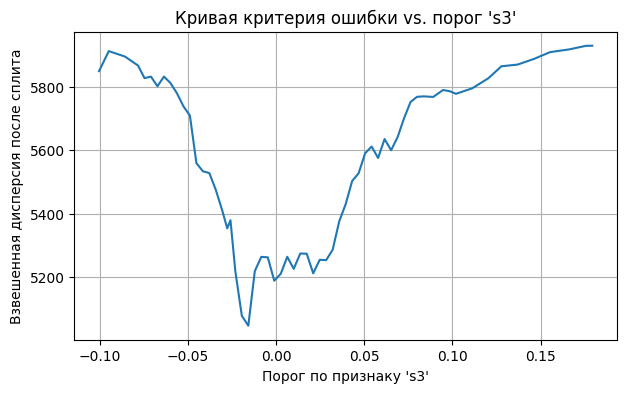

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

diab = load_diabetes()
X = pd.DataFrame(diab["data"], columns=diab["feature_names"])
y = diab["target"]

def _variance(sum_y, sum_y2, n):
    return sum_y2 / n - (sum_y / n) ** 2

def find_best_split_1d_reg(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(y)
    idx = np.argsort(x)
    x_sorted, y_sorted = x[idx], y[idx]
    diff = np.diff(x_sorted) != 0
    thresholds = (x_sorted[:-1] + x_sorted[1:]) / 2.0
    thresholds = thresholds[diff]
    split_pos = np.nonzero(diff)[0]
    n_left = split_pos + 1
    n_right = n - n_left
    csum = np.cumsum(y_sorted)
    csum2 = np.cumsum(y_sorted ** 2)
    s_left, s2_left = csum[split_pos], csum2[split_pos]
    s_right, s2_right = csum[-1] - s_left, csum2[-1] - s2_left
    var_left = _variance(s_left, s2_left, n_left)
    var_right = _variance(s_right, s2_right, n_right)
    error_after = (n_left / n) * var_left + (n_right / n) * var_right
    return thresholds, error_after

feature_name = "s3"   #['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6']

ths, errs = find_best_split_1d_reg(X[feature_name].to_numpy(), y)

plt.figure(figsize=(7,4))
plt.plot(ths, errs)
plt.xlabel(f"Порог по признаку '{feature_name}'")
plt.ylabel("Взвешенная дисперсия после сплита")
plt.title(f"Кривая критерия ошибки vs. порог '{feature_name}'")
plt.grid(True)
plt.show()


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

In [9]:

from collections import Counter
from typing import List, Union
import numpy as np

class DecisionTree:
    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification",
    ):
        if np.any(list(map(lambda x: x not in ("real", "categorical"), feature_types))):
            raise ValueError("Unknown feature type")
        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

    # обучение
    def _fit_node(self, sub_X: np.ndarray, sub_y: np.ndarray, node: dict):
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, thr_best, gain_best, split_best = None, None, -np.inf, None

        # перебираем признаки
        for feat in range(sub_X.shape[1]):
            f_type = self._feature_types[feat]
            f_vec  = sub_X[:, feat]

            _, _, thr, gain = find_best_split(f_vec, sub_y, task=self.task, feature_type=f_type)
            if gain is None:
                continue
            if gain > gain_best:
                gain_best, feature_best, thr_best = gain, feat, thr
                split_best = (f_vec <= thr_best) if f_type == "real" else (f_vec == thr_best)

        # если делить нечего - лист
        if feature_best is None or split_best.sum() == 0 or (~split_best).sum() == 0:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = thr_best
        else:
            node["category_split"] = thr_best

        # рекурсия
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split_best],  sub_y[split_best],  node["left_child"])
        self._fit_node(sub_X[~split_best], sub_y[~split_best], node["right_child"])

    # предсказание
    def _predict_node(self, x: np.ndarray, node: dict):
        if node["type"] == "terminal":
            return node["class"]

        feat = node["feature_split"]
        if self._feature_types[feat] == "real":
            go_left = x[feat] <= node["threshold"]
        else:
            go_left = x[feat] == node["category_split"]

        next_node = node["left_child"] if go_left else node["right_child"]
        return self._predict_node(x, next_node)

    # публичные методы
    def fit(self, X: np.ndarray, y: np.ndarray):
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._predict_node(x, self._tree) for x in X])

In [10]:

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Подгружаем простой датасет Iris
iris = load_iris()
X = iris.data
y = iris.target

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Указываем типы признаков
feature_types = ["real"] * X.shape[1]

# Создаём и обучаем дерево
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)

# Предсказываем на тестовой выборке
y_pred = tree.predict(X_test)

print("Предсказания дерева:", y_pred[:10])


Предсказания дерева: [1 0 2 1 1 0 1 2 1 1]


In [11]:
def print_tree(node, indent="", feature_names=None, feature_types=None):
    if node["type"] == "terminal":
        print(indent + f"Class: {node['class']}")
    else:
        feat = node["feature_split"]
        feat_name = feature_names[feat] if feature_names else f"feature_{feat}"
        if feature_types and feature_types[feat] == "real":
            print(indent + f"{feat_name} <= {node['threshold']:.3f}")
        else:
            print(indent + f"{feat_name} == {node['category_split']}")
        print(indent + "├── Left:")
        print_tree(node["left_child"], indent + "│   ", feature_names, feature_types)
        print(indent + "└── Right:")
        print_tree(node["right_child"], indent + "    ", feature_names, feature_types)

tree = DecisionTree(feature_types=["real"] * X.shape[1])
tree.fit(X_train, y_train)
print_tree(tree._tree, feature_names=iris.feature_names, feature_types=tree._feature_types)


petal length (cm) <= 2.450
├── Left:
│   Class: 0
└── Right:
    petal length (cm) <= 4.750
    ├── Left:
    │   petal width (cm) <= 1.600
    │   ├── Left:
    │   │   Class: 1
    │   └── Right:
    │       Class: 2
    └── Right:
        petal width (cm) <= 1.750
        ├── Left:
        │   petal length (cm) <= 4.950
        │   ├── Left:
        │   │   Class: 1
        │   └── Right:
        │       petal width (cm) <= 1.550
        │       ├── Left:
        │       │   Class: 2
        │       └── Right:
        │           sepal length (cm) <= 6.950
        │           ├── Left:
        │           │   Class: 1
        │           └── Right:
        │               Class: 2
        └── Right:
            petal length (cm) <= 4.850
            ├── Left:
            │   sepal length (cm) <= 5.950
            │   ├── Left:
            │   │   Class: 1
            │   └── Right:
            │       Class: 2
            └── Right:
                Class: 2


**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

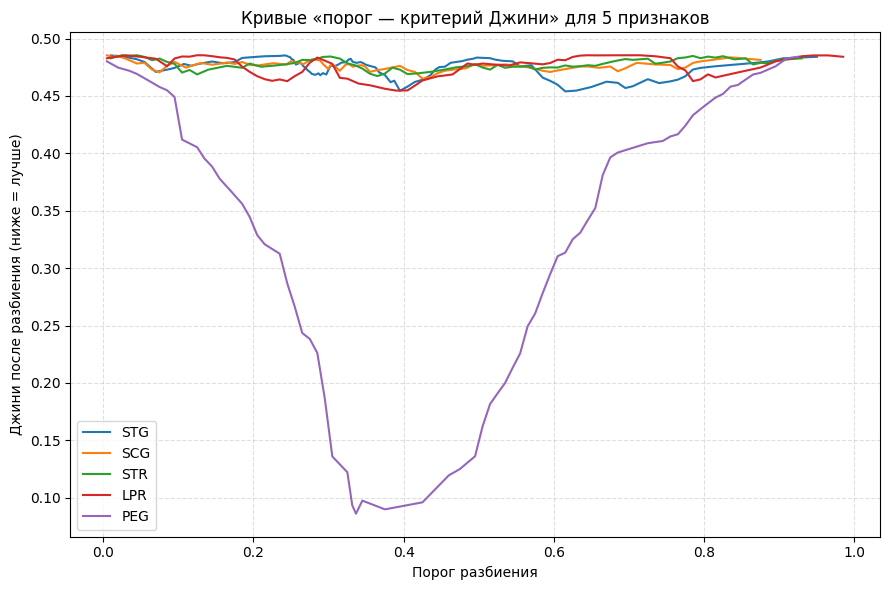

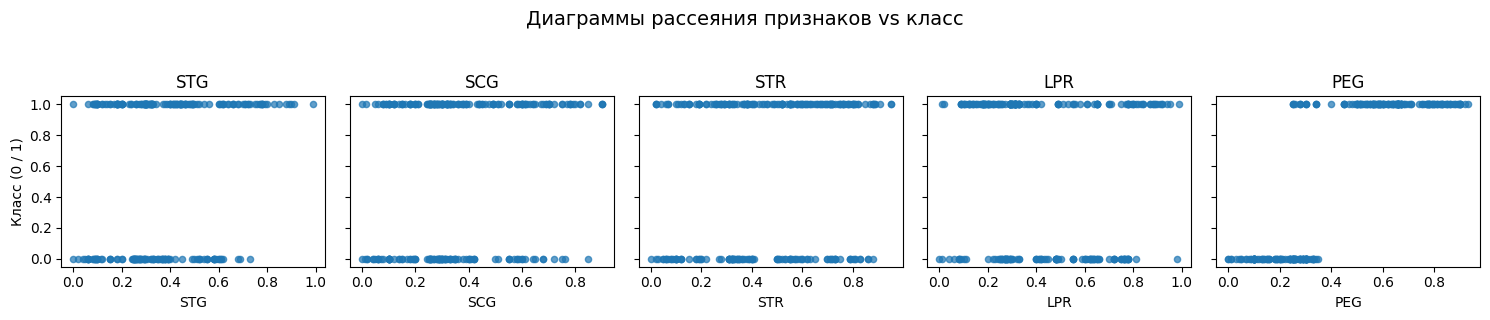

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# функция Джини после сплита
def gini_after_split(x: np.ndarray, y: np.ndarray):
    """
    x – вектор признака (1-D np.array)
    y – метки {0,1}
    Возврат: thresholds, gini_vals  (оба 1-D)
    gini_vals – значение Джини *после* разбиения (чем ниже, тем лучше)
    """
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]

    diff = np.diff(x_sorted) != 0            # где значение меняется
    thresholds = (x_sorted[:-1] + x_sorted[1:]) / 2
    thresholds = thresholds[diff]
    if thresholds.size == 0:                 # признак константный
        return thresholds, np.array([])

    split_pos = np.nonzero(diff)[0]          # индекс последнего эл-та влево
    n = len(y)
    n_left  = split_pos + 1
    n_right = n - n_left

    cum_pos = np.cumsum(y_sorted)            # сколько 1 слева
    pos_left  = cum_pos[split_pos]
    pos_right = cum_pos[-1] - pos_left

    p_left  = pos_left  / n_left
    p_right = pos_right / n_right

    g_left  = 2 * p_left  * (1 - p_left)
    g_right = 2 * p_right * (1 - p_right)

    g_after = (n_left / n) * g_left + (n_right / n) * g_right
    return thresholds, g_after

# чтение данных
df = pd.read_csv("students.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

feature_names = ["STG", "SCG", "STR", "LPR", "PEG"]
target_name   = "UNS"

X = df[feature_names].to_numpy()
y = df[target_name].to_numpy().astype(int)

# график порог – Джини для 5 признаков
plt.figure(figsize=(9, 6))
for i, name in enumerate(feature_names):
    thr, gini = gini_after_split(X[:, i], y)
    plt.plot(thr, gini, label=name)

plt.title("Кривые «порог — критерий Джини» для 5 признаков")
plt.xlabel("Порог разбиения")
plt.ylabel("Джини после разбиения (ниже = лучше)")
plt.grid(True, ls="--", alpha=.4)
plt.legend()
plt.tight_layout()
plt.show()

# диаграммы рассеяния признак – класс
fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
for ax, name in zip(axs, feature_names):
    ax.scatter(df[name], y, alpha=.7, s=20)
    ax.set_xlabel(name)
    ax.set_title(name)
axs[0].set_ylabel("Класс (0 / 1)")
plt.suptitle("Диаграммы рассеяния признаков vs класс", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [13]:
import pandas as pd
import numpy as np
from urllib.request import urlopen
from io import StringIO
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# загрузка и первичная обработка
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
raw = urlopen(url).read().decode()
df  = pd.read_csv(StringIO(raw), header=None)


# кодирование категориальных значений
encoders = {}
for col in df.columns:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc

# - target и признаки
y = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()
feature_types = ["categorical"] * X.shape[1]


# разбиение train / test  (50 % / 50 %)

rng = np.random.default_rng(seed=42)
perm = rng.permutation(len(X))
mid  = len(X) // 2
train_idx, test_idx = perm[:mid], perm[mid:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# обучение нашего дерева

tree = DecisionTree(feature_types=feature_types,
                    max_depth=None,
                    task="classification")
tree.fit(X_train, y_train)

# предсказание и качество
y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy на отложенной половине выборки: {acc:.4f}")


Accuracy на отложенной половине выборки: 1.0000


In [14]:
print(df.head())
print(df.dtypes)
print(df.nunique()) 

   0   1   2   3   4   5   6   7   8   9   ...  13  14  15  16  17  18  19  \
0   1   5   2   4   1   6   1   0   1   4  ...   2   7   7   0   2   1   4   
1   0   5   2   9   1   0   1   0   0   4  ...   2   7   7   0   2   1   4   
2   0   0   2   8   1   3   1   0   0   5  ...   2   7   7   0   2   1   4   
3   1   5   3   8   1   6   1   0   1   5  ...   2   7   7   0   2   1   4   
4   0   5   2   3   0   5   1   1   0   4  ...   2   7   7   0   2   1   0   

   20  21  22  
0   2   3   5  
1   3   2   1  
2   3   2   3  
3   2   3   5  
4   3   0   1  

[5 rows x 23 columns]
0     int64
1     int64
2     int64
3     int64
4     int64
5     int64
6     int64
7     int64
8     int64
9     int64
10    int64
11    int64
12    int64
13    int64
14    int64
15    int64
16    int64
17    int64
18    int64
19    int64
20    int64
21    int64
22    int64
dtype: object
0      2
1      6
2      4
3     10
4      2
5      9
6      2
7      2
8      2
9     12
10     2
11     5
12     4
13   

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [15]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [16]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

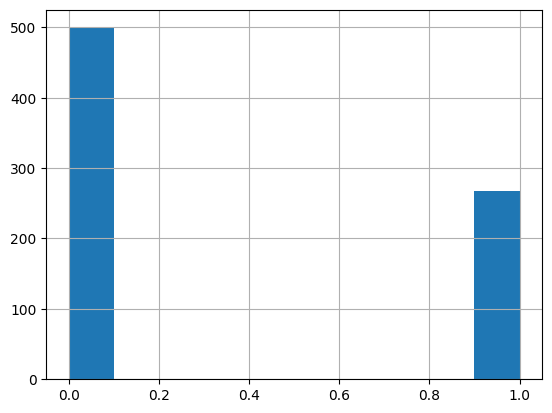

In [17]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

# загружаем данные
df = pd.read_csv("diabetes.csv")

# выделяем признаки и целевую переменную
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# разделяем на обучающую (70%) и тестовую (30%) выборки
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# делим обучающую на обучающую-обучающую (70%) и обучающую-валидационную (30%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42, stratify=y_train_full
)

# выведем пример данных и размеры
print("Пример обучающих данных:")
print(X_train.head())

print("\nРазмеры выборок:")
print("Train size (X_train):", X_train.shape)
print("Validation size (X_val):", X_val.shape)
print("Test size (X_test):", X_test.shape)


Пример обучающих данных:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
325            1      157             72             21      168  25.6   
256            3      111             56             39        0  30.1   
472            0      119             66             27        0  38.8   
278            5      114             74              0        0  24.9   
396            3       96             56             34      115  24.7   

     DiabetesPedigreeFunction  Age  
325                     0.123   24  
256                     0.557   30  
472                     0.259   22  
278                     0.744   57  
396                     0.944   39  

Размеры выборок:
Train size (X_train): (375, 8)
Validation size (X_val): (162, 8)
Test size (X_test): (231, 8)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np

# списки значений для перебора
max_depths = [3, 5, 7, 9, None]
min_samples_leafs = [1, 5, 10, 20]

best_f1 = -1
best_params = None

# перебор всех пар параметров
for max_depth in max_depths:
    for min_samples_leaf in min_samples_leafs:
        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        score = f1_score(y_val, y_val_pred)
        
        if score > best_f1:
            best_f1 = score
            best_params = (max_depth, min_samples_leaf)

print(f"Лучшая пара параметров: max_depth={best_params[0]}, min_samples_leaf={best_params[1]}")
print(f"Наилучшая f1-мера на валидации: {best_f1:.4f}")

# обучаем дерево с лучшими параметрами на полной обучающей выборке
final_model = DecisionTreeClassifier(
    max_depth=best_params[0],
    min_samples_leaf=best_params[1],
    random_state=42
)
final_model.fit(X_train_full, y_train_full)

# оценка на тестовой выборке
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_prob)

print("\nМетрики на тестовой выборке:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"AUC ROC:   {auc:.4f}")


Лучшая пара параметров: max_depth=5, min_samples_leaf=20
Наилучшая f1-мера на валидации: 0.6250

Метрики на тестовой выборке:
Accuracy:  0.7273
Precision: 0.6452
Recall:    0.4938
AUC ROC:   0.7951


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [21]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),  # ← новое имя параметра
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train_full, y_train_full)

y_pred_bag = bagging.predict(X_test)
y_prob_bag = bagging.predict_proba(X_test)[:, 1]


# Метрики
acc_bag = accuracy_score(y_test, y_pred_bag)
prec_bag = precision_score(y_test, y_pred_bag)
rec_bag = recall_score(y_test, y_pred_bag)
auc_bag = roc_auc_score(y_test, y_prob_bag)

# Вывод результатов
print("BaggingClassifier (50 деревьев):")
print(f"Accuracy:  {acc_bag:.4f}")
print(f"Precision: {prec_bag:.4f}")
print(f"Recall:    {rec_bag:.4f}")
print(f"AUC ROC:   {auc_bag:.4f}")


BaggingClassifier (50 деревьев):
Accuracy:  0.7532
Precision: 0.6875
Recall:    0.5432
AUC ROC:   0.8269


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

max_depths = [3, 5, 7, 10, None]
min_samples_splits = [2, 5, 10]
best_score = -1
best_params = None

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for depth in max_depths:
    for min_split in min_samples_splits:
        f1_scores = []
        for train_idx, val_idx in skf.split(X_train_full, y_train_full):
            X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
            model = RandomForestClassifier(n_estimators=50, max_depth=depth, min_samples_split=min_split, random_state=42)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            f1_scores.append(f1_score(y_val, preds))
        mean_score = np.mean(f1_scores)
        if mean_score > best_score:
            best_score = mean_score
            best_params = (depth, min_split)

print(f"Best params: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
print(f"Best average F1 score: {best_score:.4f}")

# Обучаем модель с лучшими параметрами на всей обучающей выборке
rf_best = RandomForestClassifier(n_estimators=50, max_depth=best_params[0],
                                 min_samples_split=best_params[1], random_state=42)
rf_best.fit(X_train_full, y_train_full)

# Метрики на тесте
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

print("Random Forest (best params):")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("AUC ROC:  ", roc_auc_score(y_test, y_proba))


Best params: max_depth=None, min_samples_split=5
Best average F1 score: 0.6420
Random Forest (best params):
Accuracy:  0.7359307359307359
Precision: 0.65625
Recall:    0.5185185185185185
AUC ROC:   0.8198353909465022


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

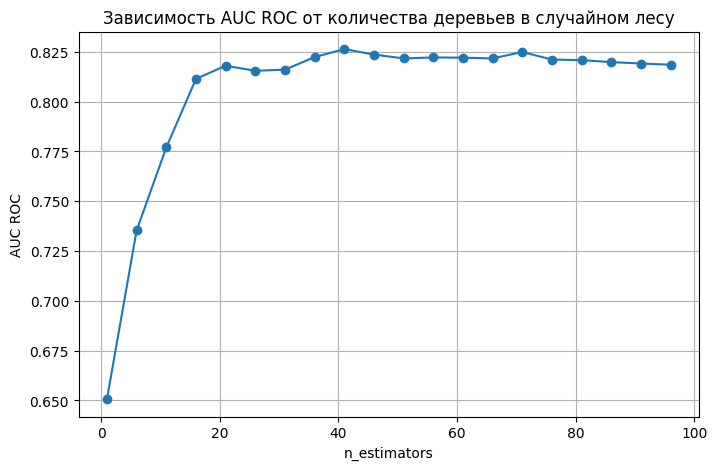

In [23]:
n_estimators_list = list(range(1, 101, 5))
auc_scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_full, y_train_full)
    y_proba = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores.append(auc)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, auc_scores, marker='o')
plt.title("Зависимость AUC ROC от количества деревьев в случайном лесу")
plt.xlabel("n_estimators")
plt.ylabel("AUC ROC")
plt.grid(True)
plt.show()


**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

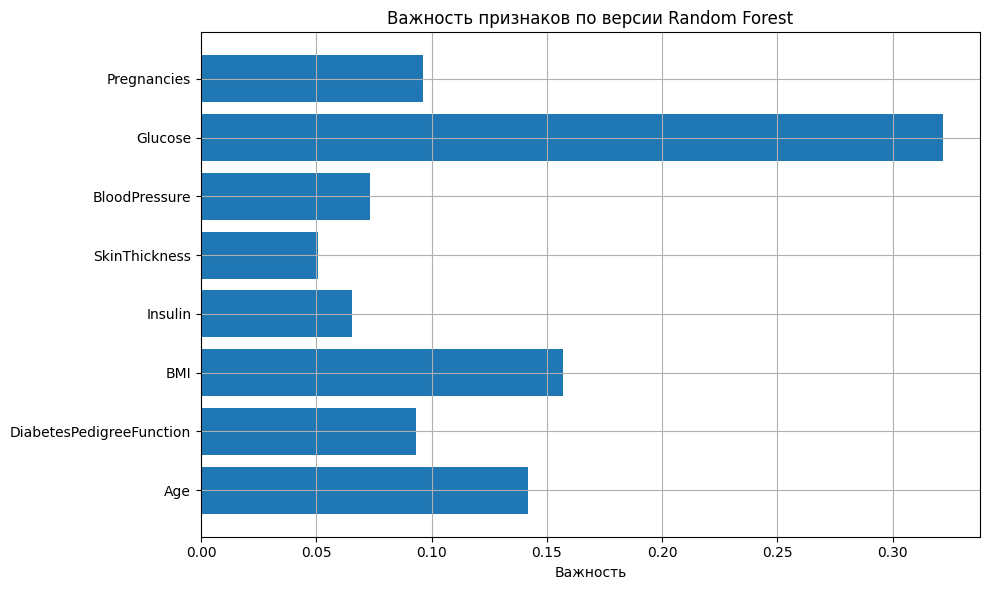

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("diabetes.csv")
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

best_max_depth = 6
best_min_samples_split = 4

# Обучаем модель
rf_best = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    random_state=42
)
rf_best.fit(X_train_full, y_train_full)

# Важности признаков
importances = rf_best.feature_importances_
features = X.columns

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Важность")
plt.title("Важность признаков по версии Random Forest")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
import numpy as np

imp = rf_best.feature_importances_
best_feat = X.columns[np.argmax(imp)]
print(f"Самый значимый признак: {best_feat}  (важность = {imp.max():.3f})")

Самый значимый признак: Glucose  (важность = 0.322)
